In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
import io
from google.colab import files

datapath = '/content/drive/My Drive/Ph. D. Research/CESMII Project/'

In [2]:
!pip install simantha

In [16]:
import random
from simantha import Source, Machine, Buffer, Sink, Maintainer, System, utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
datapath = 

In [4]:
degradation_matrix = [
    [0.9, 0.1, 0.,  0.,  0. ],
    [0.,  0.9, 0.1, 0.,  0. ],
    [0.,  0.,  0.9, 0.1, 0. ],
    [0.,  0.,  0.,  0.9, 0.1],
    [0.,  0.,  0.,  0.,  1. ]
]

cbm_threshold = 3

pm_distribution = {'geometric': 0.25}

cm_distribution = {'geometric': 0.10}

In [5]:
source = Source()

M1 = Machine(
    name='M1', 
    cycle_time=1,
    degradation_matrix=degradation_matrix,
    cbm_threshold=cbm_threshold,
    pm_distribution=pm_distribution,
    cm_distribution=cm_distribution
)

B1 = Buffer(capacity=10)

M2 = Machine(
    name='M2', 
    cycle_time=2,
    degradation_matrix=degradation_matrix,
    cbm_threshold=cbm_threshold,
    pm_distribution=pm_distribution,
    cm_distribution=cm_distribution
)

sink = Sink()

objects = [source, M1, B1, M2, sink]

In [6]:
source.define_routing(downstream=[M1])
M1.define_routing(upstream=[source], downstream=[B1])
B1.define_routing(upstream=[M1], downstream=[M2])
M2.define_routing(upstream=[B1], downstream=[sink])
sink.define_routing(upstream=[M2])

In [7]:
maintainer = Maintainer(capacity=1)

system = System(objects=objects, maintainer=maintainer)

In [8]:
random.seed(1)
system.simulate(simulation_time=utils.WEEK)

Simulation finished in 0.57s
Parts produced: 4344


### **Machine**

1.   production_data
2.   health_data
3.   maintenance_data

### **Buffer**

1.   level_data





In [15]:
print(pd.DataFrame(M1.production_data).head(5))
print('\n')
print(pd.DataFrame(M2.production_data).head(5))
print('\n')
print(pd.DataFrame(M1.health_data).head(5))
print('\n')
print(pd.DataFrame(M2.health_data).head(5))
print('\n')
print(pd.DataFrame(M1.maintenance_data).head(10))
print('\n')
print(pd.DataFrame(M2.maintenance_data).head(10))

   time  production
0     0           0
1     1           1
2     2           2
3     3           3
4     4           4


   time  production
0     0           0
1     3           1
2     5           2
3     7           3
4     9           4


   time  health
0     0       0
1    18       1
2    20       2
3    26       3
4    30       0


   time  health
0     0       0
1     4       1
2    24       2
3    30       3
4    31       0


   time              event
0    26        enter queue
1    26  begin maintenance
2    30           repaired
3    43        enter queue
4    43  begin maintenance
5    46           repaired
6    68        enter queue
7    68  begin maintenance
8    71           repaired
9    90        enter queue


   time              event
0    30        enter queue
1    30  begin maintenance
2    31           repaired
3    74        enter queue
4    74  begin maintenance
5    85           repaired
6   100        enter queue
7   102  begin maintenance
8   116           

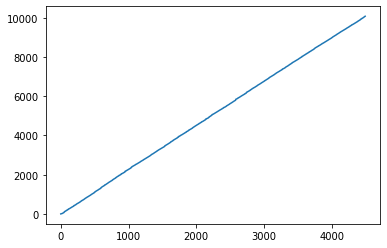

In [18]:
plt.plot(M1.production_data['production'], M1.production_data['time'])

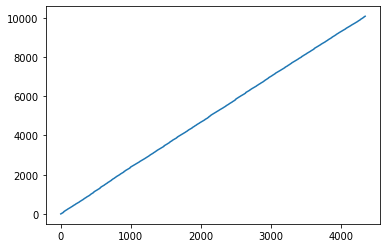

In [21]:
plt.plot(M2.production_data['production'], M2.production_data['time'])

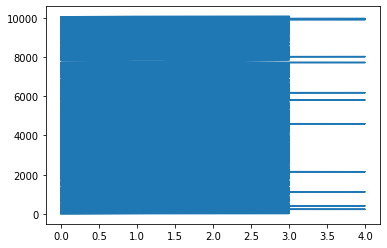

In [24]:
plt.plot(M1.health_data['health'], M1.health_data['time'])

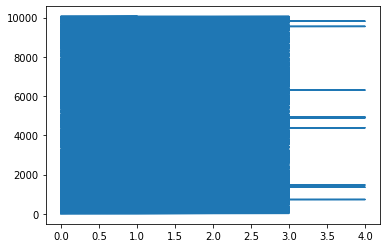

In [25]:
plt.plot(M2.health_data['health'], M2.health_data['time'])

In [33]:
pd.DataFrame(M1.production_data).to_csv(datapath + 'M1_production_data.csv')

In [34]:
pd.DataFrame(M2.production_data).to_csv(datapath + 'M2_production_data.csv')

In [35]:
pd.DataFrame(M1.health_data).to_csv(datapath + 'M1_health_data.csv')

In [36]:
pd.DataFrame(M2.health_data).to_csv(datapath + 'M2_health_data.csv')

In [43]:
df = pd.read_csv(datapath + 'M1_production_data_edit.csv')

In [44]:
df.head()

,Unnamed: 0,time,production,timediff,productioncdiff
0,0,0,0,0,0
1,1,1,1,1,1
2,2,2,2,1,1
3,3,3,3,1,1
4,4,4,4,1,1


In [38]:
font = {'family': 'calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 16,
        }
#'sans serif',

No handles with labels found to put in legend.


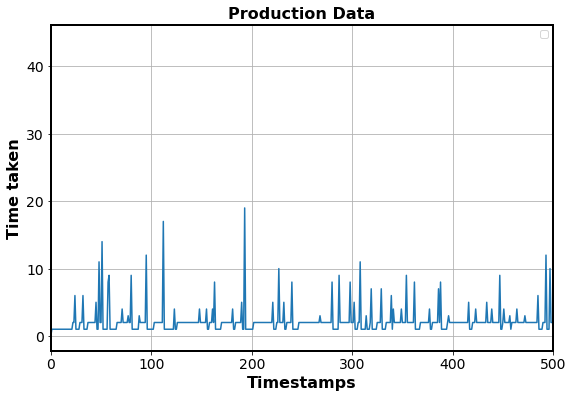

In [47]:
plt.plot(df['timediff'])

plt.title('Production Data', fontdict = font) 

#plt.ylabel('No. of Parts Produced', fontdict = font)
plt.ylabel('Time taken', fontdict = font)
plt.xlabel('Timestamps', fontdict = font)

#plt.ylim((0, 2e-07))
#plt.ylim((1e-06, 15e-06))
plt.xlim(0, 500)

plt.legend(loc = 'upper right')
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid()
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 2
plt.rcParams["figure.figsize"] = (9, 6)